<a href="https://colab.research.google.com/github/AstronomekDomansky/-.-1/blob/main/%D0%A1%D0%B8%D0%B8%D0%91%D0%943.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическая работа 3. Агрегирование и группировка в Pandas

**Тема.** Функции `sum`, `mean`, `min`, `max` и другие; группировка `groupby`; сводные таблицы `pivot_table`; работа с датой из Unix-времени.

Группировка отвечает на вопросы вида «какая средняя температура **у каждого** датчика?» без ручного фильтра на устройство. Схема всегда одна: **разбить** таблицу на куски → **посчитать** в куске статистику → **собрать** ответ.


**Рисунок. Схема split–apply–combine: разбить, применить функцию, собрать**

![Схема split–apply–combine: разбить, применить функцию, собрать](https://pandas.pydata.org/docs/_images/06_groupby.svg)

Источник: документация pandas, схема 06_groupby


**Данные.** Та же телеметрия датчиков среды, что на практике 1: `ts`, `device`, `co`, `lpg`, `smoke`, `humidity`, `light`, `motion`, `temp`. Загрузка может занять полминуты.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://drive.google.com/uc?export=download&id=1MVbh3ReFZEw3uKreAj2s0ftYiUHvT0qa"
df = pd.read_csv(url)
df.head()


,ts,device,co,humidity,light,lpg,motion,smoke,temp
0,1.595201e+09,b8:27:eb:bf:9d:51,0.005951,49.400000,False,0.008733,False,0.023511,21.500000
1,1.594665e+09,00:0f:00:70:91:0a,0.004878,74.599998,False,0.007563,False,0.020162,19.100000
2,1.595000e+09,1c:bf:ce:15:ec:4d,0.004009,69.699997,True,0.006563,False,0.017327,25.900000
3,1.594591e+09,b8:27:eb:bf:9d:51,0.005304,51.700000,False,0.008036,False,0.021509,22.100000
4,1.595176e+09,00:0f:00:70:91:0a,0.002216,76.099998,False,0.004275,False,0.010960,19.299999


---
# 1. Агрегаты по столбцу

Агрегат сжимает много чисел в одно значение или в короткую таблицу.

| Метод | Что считает |
|---|---|
| `nunique()` | сколько **разных** значений |
| `value_counts()` | сколько раз встретилось каждое значение |
| `min()` / `max()` | минимум / максимум |
| `sum()` | сумма |
| `mean()` | среднее арифметическое |
| `std()` | стандартное отклонение (разброс) |
| `quantile(0.95)` | 95-й процентиль |
| `diff()` | разность с **предыдущей** строкой |
| `sort_values(by=...)` | сортировка строк |

`df.max()` без имени столбца идёт по всем полям. Для текста это «последнее» слово по алфавиту — для датчиков обычно ограничиваются `numeric_only=True`.


In [ ]:
print("Уникальных устройств:", df["device"].nunique())
print()
print("Сколько строк у каждого устройства:")
print(df["device"].value_counts())


Уникальных устройств: 3

Сколько строк у каждого устройства:
device
b8:27:eb:bf:9d:51    150065
00:0f:00:70:91:0a     89462
1c:bf:ce:15:ec:4d     84620
Name: count, dtype: int64


In [ ]:
print("Сортировка по температуре (самые холодные сверху):")
display(df.sort_values(by="temp").head())

print("Минимальная влажность:", df["humidity"].min())
print("Максимумы по числовым столбцам:")
print(df.max(numeric_only=True))


Сортировка по температуре (самые холодные сверху):


,ts,device,co,humidity,light,lpg,motion,smoke,temp
163600,1.595156e+09,1c:bf:ce:15:ec:4d,0.004630,58.000000,True,0.007283,False,0.019366,0.0
158937,1.595157e+09,1c:bf:ce:15:ec:4d,0.004566,58.200001,True,0.007210,False,0.019158,0.0
308576,1.594905e+09,00:0f:00:70:91:0a,0.002613,67.099998,False,0.004815,False,0.012445,0.0
247614,1.595085e+09,00:0f:00:70:91:0a,0.003527,69.000000,False,0.005982,False,0.015694,0.0
35552,1.595183e+09,00:0f:00:70:91:0a,0.002414,76.699997,False,0.004547,False,0.011708,0.0


Минимальная влажность: 1.100000023841858
Максимумы по числовым столбцам:
ts          1595203416.979522
co                   0.013505
humidity            99.900002
light                    True
lpg                    0.0158
motion                   True
smoke                0.044288
temp                     30.6
dtype: object


In [ ]:
print("Сумма столбца smoke:", df["smoke"].sum())
print("Средняя температура:", df["temp"].mean())

humidity_diff = df["humidity"].diff()
print("Первые разности влажности (у первой строки NaN — сравнивать не с чем):")
print(humidity_diff.head())


Сумма столбца smoke: 6244.161235511432
Средняя температура: 22.453749400696044
Первые разности влажности (у первой строки NaN — сравнивать не с чем):
0          NaN
1    25.199998
2    -4.900002
3   -17.999997
4    24.399998
Name: humidity, dtype: float64


`diff()` имеет смысл, когда строки идут **по времени одного прибора**. В перемешанном файле это просто «минус соседняя строка», а не динамика датчика. Перед анализом рядов данные сортируют по `device` и `ts`.

Копия таблицы нужна, чтобы эксперимент не затёр исходник. Ниже в копии столбец `light` принудительно ставится в `True` — как в основном ноутбуке. Исходный `df` не меняется.


In [ ]:
df_copy = df.copy()
df_copy["light"] = True
print("В копии уникальные light:", df_copy["light"].unique())
print("В исходнике по-прежнему:", df["light"].unique())
df_copy.head(3)


В копии уникальные light: [ True]
В исходнике по-прежнему: [False  True]


,ts,device,co,humidity,light,lpg,motion,smoke,temp
0,1.595201e+09,b8:27:eb:bf:9d:51,0.005951,49.400000,True,0.008733,False,0.023511,21.5
1,1.594665e+09,00:0f:00:70:91:0a,0.004878,74.599998,True,0.007563,False,0.020162,19.1
2,1.595000e+09,1c:bf:ce:15:ec:4d,0.004009,69.699997,True,0.006563,False,0.017327,25.9


---
# 2. Группировка: groupby

Базовый шаблон:

```python
df.groupby("device")["temp"].mean()
```

Читается: разбить по `device` → взять столбец `temp` → среднее в каждой группе.

`df.groupby("device").mean(numeric_only=True)` усредняет **все** числовые столбцы. Аргумент `numeric_only=True` в новых версиях pandas обязателен, иначе библиотека попытается усреднить текст.


In [ ]:
print("Средние числовые признаки по устройствам:")
display(df.groupby("device").mean(numeric_only=True))

print("Только средняя температура:")
print(df.groupby("device")["temp"].mean())


Средние числовые признаки по устройствам:


,ts,co,humidity,light,lpg,motion,smoke,temp
device,,,,,,,,
00:0f:00:70:91:0a,1.594859e+09,0.003526,75.446245,0.032595,0.005893,0.000022,0.015487,19.363663
1c:bf:ce:15:ec:4d,1.594857e+09,0.004182,61.930347,1.000000,0.006763,0.003214,0.017893,26.029407
b8:27:eb:bf:9d:51,1.594858e+09,0.005559,50.817530,0.015853,0.008306,0.000813,0.022287,22.279646


Только средняя температура:
device
00:0f:00:70:91:0a    19.363663
1c:bf:ce:15:ec:4d    26.029407
b8:27:eb:bf:9d:51    22.279646
Name: temp, dtype: float64


**Именованные агрегаты** через `.agg` позволяют в одном запросе получить среднее, квантиль и разброс с понятными именами столбцов.

- `size()` — сколько строк в группе (не путать с `count()`, который пропускает NaN).
- `value_counts(normalize=True)` внутри группы — доли, например как часто было движение у каждого устройства.


In [ ]:
summary = df.groupby("device").agg(
    temp_mean=("temp", "mean"),
    temp_p95=("temp", lambda s: s.quantile(0.95)),
    hum_std=("humidity", "std"),
    co_min=("co", "min"),
    n=("temp", "size"),
)
display(summary)

print("\nЧисло строк (size):")
print(df.groupby("device").size())

print("\nДоли motion внутри устройства:")
print(df.groupby("device")["motion"].value_counts(normalize=True))


,temp_mean,temp_p95,hum_std,co_min,n
device,,,,,
00:0f:00:70:91:0a,19.363663,20.0,1.969156,0.001171,89462
1c:bf:ce:15:ec:4d,26.029407,29.5,8.955952,0.003391,84620
b8:27:eb:bf:9d:51,22.279646,23.1,1.888309,0.004646,150065



Число строк (size):
device
00:0f:00:70:91:0a     89462
1c:bf:ce:15:ec:4d     84620
b8:27:eb:bf:9d:51    150065
dtype: int64

Доли motion внутри устройства:
device             motion
00:0f:00:70:91:0a  False     0.999978
                   True      0.000022
1c:bf:ce:15:ec:4d  False     0.996786
                   True      0.003214
b8:27:eb:bf:9d:51  False     0.999187
                   True      0.000813
Name: proportion, dtype: float64


## Фильтр групп

`groupby(...).filter(функция)` оставляет **все исходные строки** тех групп, для которых функция вернула `True`. Это не среднее по группе, а отбор целых устройств.

Пример из основного ноутбука: оставить устройства со средней температурой выше 25 °C.

- средняя 21 °C — устройство выкидывается целиком;
- средняя 27 °C — все его строки остаются, без усреднения.


In [ ]:
warm_devices = df.groupby("device").filter(lambda g: g["temp"].mean() > 25)
print("Строк после фильтра:", len(warm_devices), "из", len(df))
print("Какие устройства остались:")
print(warm_devices["device"].unique())


Строк после фильтра: 84620 из 324147
Какие устройства остались:
['1c:bf:ce:15:ec:4d']


## Строка-рекордсмен в каждой группе

`idxmax()` после `groupby("device")["temp"]` даёт **индекс строки**, где температура максимальна у данного устройства. `df.loc[idx]` достаёт полные строки — все столбцы, не только температуру.

Если у устройства A максимум 30 °C в строке №5, а у B — 28 °C в строке №12, в результат попадут именно эти две строки.


In [ ]:
idx = df.groupby("device")["temp"].idxmax()
hottest = df.loc[idx]
display(hottest[["device", "ts", "temp", "humidity", "motion", "light"]])


,device,ts,temp,humidity,motion,light
9444,00:0f:00:70:91:0a,1.594935e+09,20.200001,75.800003,False,False
126,1c:bf:ce:15:ec:4d,1.595110e+09,30.600000,52.500000,False,True
1858,b8:27:eb:bf:9d:51,1.594846e+09,24.100000,50.600000,False,False


Столбчатая диаграмма — тот же `groupby`, только нарисованный. MAC-адрес целиком не читается, поэтому на оси оставляем последние 8 символов.


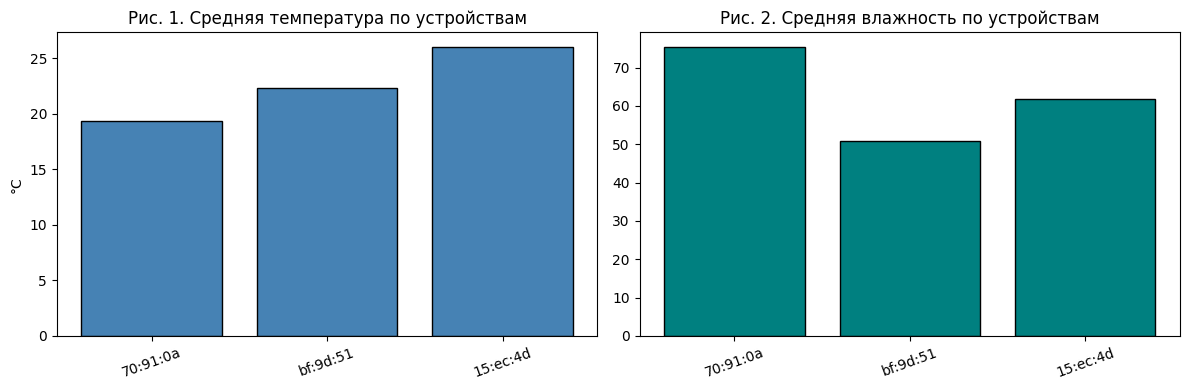

In [ ]:
temp_by_dev = df.groupby("device")["temp"].mean().sort_values()
hum_by_dev = df.groupby("device")["humidity"].mean().reindex(temp_by_dev.index)
labels = [d[-8:] for d in temp_by_dev.index]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(labels, temp_by_dev.values, color="steelblue", edgecolor="black")
axes[0].set_title("Рис. 1. Средняя температура по устройствам")
axes[0].set_ylabel("°C")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(labels, hum_by_dev.values, color="teal", edgecolor="black")
axes[1].set_title("Рис. 2. Средняя влажность по устройствам")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


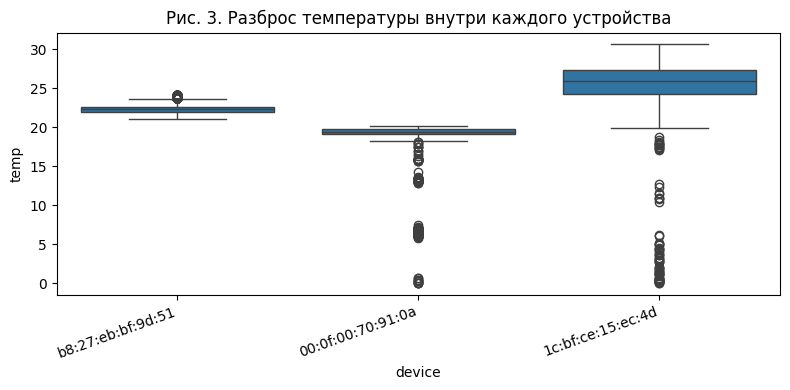

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="device", y="temp")
plt.xticks(rotation=20, ha="right")
plt.title("Рис. 3. Разброс температуры внутри каждого устройства")
plt.tight_layout()
plt.show()


Среднее на bar-чарте может совпадать у двух устройств, а boxplot покажет: у одного узкий «ящик», у другого длинные усы. Для настройки порогов тревоги важен разброс, не только среднее.


## Z-оценка внутри группы

Сравнивать «сырую» температуру разных датчиков нечестно, если один висит у батареи, а другой у окна. Z-оценка **внутри устройства** отвечает: насколько это измерение необычно **для данного** прибора.


$$temp_z = (temp - mean_{device}) / std_{device}$$


После преобразования среднее `temp_z` у каждого устройства ≈ 0, стандартное отклонение ≈ 1. Реализация — `groupby(...).transform(...)`: функция считается в группе, результат **приклеивается обратно к каждой строке** (в отличие от `agg`, который сжимает группу в одну строку).


In [ ]:
df["temp_z"] = df.groupby("device")["temp"].transform(
    lambda s: (s - s.mean()) / s.std()
)
check = df.groupby("device")["temp_z"].agg(["mean", "std"])
display(check)
print("\n")
display(df[["device", "temp", "temp_z"]].head())


,mean,std
device,,
00:0f:00:70:91:0a,3.752693e-15,1.0
1c:bf:ce:15:ec:4d,1.476839e-15,1.0
b8:27:eb:bf:9d:51,7.839773e-15,1.0


,device,temp,temp_z
0,b8:27:eb:bf:9d:51,21.500000,-1.619909
1,00:0f:00:70:91:0a,19.100000,-0.409787
2,1c:bf:ce:15:ec:4d,25.900000,-0.063860
3,b8:27:eb:bf:9d:51,22.100000,-0.373260
4,00:0f:00:70:91:0a,19.299999,-0.098947


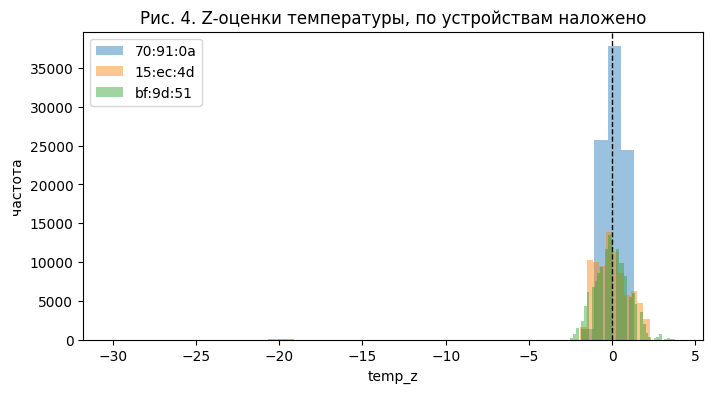

In [ ]:
plt.figure(figsize=(8, 4))
for dev, part in df.groupby("device"):
    plt.hist(part["temp_z"], bins=40, alpha=0.45, label=str(dev)[-8:])
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.title("Рис. 4. Z-оценки температуры, по устройствам наложено")
plt.xlabel("temp_z")
plt.ylabel("частота")
plt.legend()
plt.show()


---
# 3. Сводная таблица pivot_table

`pivot_table` — родственник `groupby`, но результат сразу раскладывается в сетку: строки × столбцы × значения.

| Аргумент | Роль |
|---|---|
| `values` | что усредняем / суммируем |
| `index` | что идёт в строки |
| `columns` | что идёт в столбцы |
| `aggfunc` | `mean`, `max` или словарь функций |
| `margins=True` | строка и столбец итогов All |


In [ ]:
print("1) Средняя температура по устройствам")
display(pd.pivot_table(df, values="temp", index="device", aggfunc="mean"))

print("\n2) Средняя temp и максимальная humidity")
display(pd.pivot_table(
    df,
    values=["temp", "humidity"],
    index="device",
    aggfunc={"temp": "mean", "humidity": "max"},
))


1) Средняя температура по устройствам


,temp
device,
00:0f:00:70:91:0a,19.363663
1c:bf:ce:15:ec:4d,26.029407
b8:27:eb:bf:9d:51,22.279646



2) Средняя temp и максимальная humidity


,humidity,temp
device,,
00:0f:00:70:91:0a,99.900002,19.363663
1c:bf:ce:15:ec:4d,92.000000,26.029407
b8:27:eb:bf:9d:51,63.300000,22.279646


Параметр `columns` добавляет второе измерение. Строки — устройства, столбцы — был свет или нет, в ячейках — средняя температура. Так сравнивают поведение прибора «при свете» и «в темноте» без двух отдельных фильтров.


In [ ]:
print("3) Температура: устройство × свет")
piv_light = pd.pivot_table(
    df, values="temp", index="device", columns="light", aggfunc="mean"
)
display(piv_light)

print("\n4) Дым: устройство × движение")
piv_motion = pd.pivot_table(
    df, values="smoke", index="device", columns="motion", aggfunc="mean"
)
display(piv_motion)

print("\n5) Температура × свет с итогами margins=True")
display(pd.pivot_table(
    df, values="temp", index="device", columns="light",
    aggfunc="mean", margins=True,
))


3) Температура: устройство × свет


light,False,True
device,,
00:0f:00:70:91:0a,19.370174,19.170405
1c:bf:ce:15:ec:4d,NaN,26.029407
b8:27:eb:bf:9d:51,22.279207,22.306936



4) Дым: устройство × движение


motion,False,True
device,,
00:0f:00:70:91:0a,0.015487,0.009742
1c:bf:ce:15:ec:4d,0.017892,0.018152
b8:27:eb:bf:9d:51,0.022287,0.022040



5) Температура × свет с итогами margins=True


light,False,True,All
device,,,
00:0f:00:70:91:0a,19.370174,19.170405,19.363663
1c:bf:ce:15:ec:4d,NaN,26.029407,26.029407
b8:27:eb:bf:9d:51,22.279207,22.306936,22.279646
All,21.204353,25.708475,22.453749


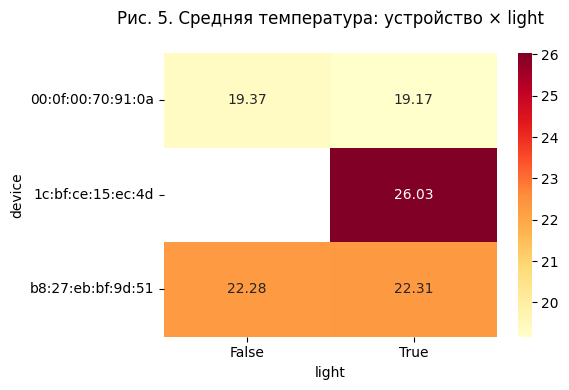

In [ ]:
plt.figure(figsize=(6, 4))
sns.heatmap(piv_light, annot=True, fmt=".2f", cmap="YlOrRd")
plt.title("Рис. 5. Средняя температура: устройство × light\n")
plt.tight_layout()
plt.show()


## Дата из Unix-времени

`ts` — секунды с 1 января 1970 года. `pd.to_datetime(..., unit="s")` превращает их в нормальную дату и время. Дальше можно строить сводку «день × устройство».

`.dt.date` оставляет календарный день без часов — удобно для суточных средних.


In [ ]:
df["datetime"] = pd.to_datetime(df["ts"], unit="s")
df["date"] = df["datetime"].dt.date

print("Диапазон времени:", df["datetime"].min(), "—", df["datetime"].max())

daily = pd.pivot_table(
    df,
    values="temp",
    index="date",
    columns="device",
    aggfunc="mean",
)
display(daily.head(10))


Диапазон времени: 2020-07-12 00:01:34.385974646 — 2020-07-20 00:03:36.979521513


device,00:0f:00:70:91:0a,1c:bf:ce:15:ec:4d,b8:27:eb:bf:9d:51
date,,,
2020-07-12,19.281314,26.246223,21.812866
2020-07-13,19.249846,24.865992,21.999979
2020-07-14,19.532716,24.773381,22.576610
2020-07-15,19.301314,26.551093,22.749327
2020-07-16,19.179163,25.970054,22.328924
2020-07-17,19.504954,25.163574,22.211938
2020-07-18,19.472529,26.730775,22.323621
2020-07-19,19.379919,27.853035,22.232606
2020-07-20,19.267742,26.604000,22.528000


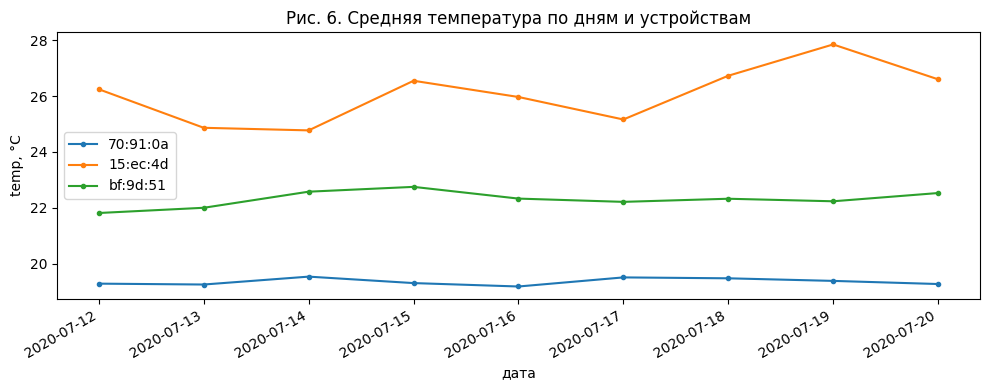

In [ ]:
plt.figure(figsize=(10, 4))
for col in daily.columns:
    plt.plot(daily.index, daily[col], marker="o", markersize=3, label=str(col)[-8:])
plt.title("Рис. 6. Средняя температура по дням и устройствам")
plt.xlabel("дата")
plt.ylabel("temp, °C")
plt.legend()
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## Категория температуры и сводка по ней

Иногда непрерывный признак удобно разрезать на подписи. Ниже — три корзины, как часто делают при разведочном анализе:

- «Холодно», если `temp < 20`;
- «Нормально», если `20 ≤ temp ≤ 25`;
- «Жарко», если `temp > 25`.

`np.select` проверяет условия по порядку и подставляет подпись. Затем те же `groupby` / `pivot_table` работают уже с категорией.


In [ ]:
conditions = [df["temp"] < 20, df["temp"] > 25]
choices = ["Холодно", "Жарко"]
df["temp_category"] = np.select(conditions, choices, default="Нормально")

print(df["temp_category"].value_counts(), "\n")

by_cat = df.groupby("temp_category").agg(
    smoke_mean=("smoke", "mean"),
    co_mean=("co", "mean"),
    n=("temp", "size"),
)
display(by_cat)

print("\nСводка по устройству и движению (средняя температура):\n")
display(pd.pivot_table(
    df, values="temp", index="device", columns="motion", aggfunc="mean"
))


temp_category
Нормально    183934
Холодно       84849
Жарко         55364
Name: count, dtype: int64 



,smoke_mean,co_mean,n
temp_category,,,
Жарко,0.017937,0.004196,55364
Нормально,0.021358,0.005272,183934
Холодно,0.015589,0.003556,84849



Сводка по устройству и движению (средняя температура):



motion,False,True
device,,
00:0f:00:70:91:0a,19.363656,19.650000
1c:bf:ce:15:ec:4d,26.026847,26.823162
b8:27:eb:bf:9d:51,22.279648,22.277869


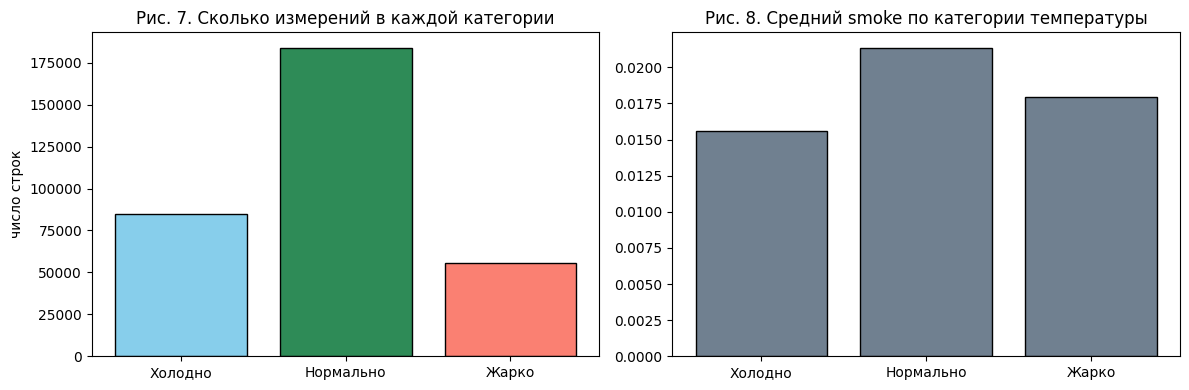

In [ ]:
order = ["Холодно", "Нормально", "Жарко"]
counts = df["temp_category"].value_counts().reindex(order)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(counts.index, counts.values, color=["skyblue", "seagreen", "salmon"], edgecolor="black")
axes[0].set_title("Рис. 7. Сколько измерений в каждой категории")
axes[0].set_ylabel("число строк")

axes[1].bar(by_cat.reindex(order).index, by_cat.reindex(order)["smoke_mean"],
            color="slategray", edgecolor="black")
axes[1].set_title("Рис. 8. Средний smoke по категории температуры")
plt.tight_layout()
plt.show()


Если средний `smoke` растёт вместе с категорией «Жарко», газы и температура в этом наборе идут рядом — имеет смысл позже посмотреть корреляцию и scatter. Если столбики почти равны, температура сама по себе дым не объясняет.
